# Selected Dataset
- CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class.  More info [here](https://www.cs.toronto.edu/~kriz/cifar.html)

## 1) Data Preprocessing

- Import first all external libraries, dependencies and packages required overall for the completion of the exercise.
- Main configuration object where it can be easily configured to tune further on desired (hyper)parameters to adjust and experiment as needed.
- Data loading and preprocessing (e.g., normalization, resizing, augmentation).
- Data visualizaction: some images, and labels.

In [1]:
import numpy as np
import os
import pickle
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from google.colab import drive


- Used google drive to properly read the already downloaded dataset there, also it helps to export the already trained model to save it as history for further examination.

In [ ]:
drive.mount('/content/drive')

CONFIG = {
    "DATA_PATH": "cifar-10-batches-py", # Path to your extracted CIFAR-10 directory (to run it locally)
    "DRIVE_DATA_PATH": "/content/drive/MyDrive/master/project-1-deep-learning-image-classification-with-cnn/cifar-10-batches-py",
    "DRIVE_DATA_MODELS_PATH": "/content/drive/MyDrive/master/project-1-deep-learning-image-classification-with-cnn/saved-models",
    "VALIDATION_SPLIT": 0.2,
    "RANDOM_SEED": 42,

    # Augmentation parameters
    "RANDOM_ROTATION": 0.02,
    "RANDOM_ZOOM": 0.1,

    # Model Hyperparameters
    "LEARNING_RATE": 1e-3,
    "OPTIMIZER": Adam,

    # Training Hyperparameters
    "EPOCHS": 100,
    "BATCH_SIZE": 64, # Common sizes: 32, 64, 128

    # Callback Configuration
    "ES_PATIENCE": 10,
    "ES_MONITORED_VARIABLE": "val_loss",
    "RLR_PATIENCE": 5,
    "RLR_FACTOR": 0.2,
    "RLR_MONITORED_VARIABLE": "val_loss",
    "RLR_MIN_LR": 1e-6,

    # Image Configuration
    "IMG_HEIGHT": 32,
    "IMG_WIDTH": 32,
    "IMG_CHANNELS": 3
}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- Helper functions to import cifar data.
  - each batch loader, load range of batches.
- An important remark is the images normalization, as each pixel information is set between 0 and 1.

In [ ]:
def load_cifar_batch(filename):
    with open(filename, 'rb') as file:
        data_dict = pickle.load(file, encoding='bytes')
        images = data_dict[b'data']
        labels = data_dict[b'labels']
    return images, labels

def reshape_and_normalize(images_flat):
    # 1. Reshape from (N, 3072) to (N, 3, 32, 32) (channels-first)
    images = images_flat.reshape(-1, 3, CONFIG["IMG_HEIGHT"], CONFIG["IMG_WIDTH"])
    # 2. Transpose from (N, C, H, W) to (N, H, W, C) (channels-last for TF)
    images = images.transpose(0, 2, 3, 1)
    # 3. Normalize pixels to [0, 1]
    images = images.astype('float32') / 255.0
    return images

def load_cifar_data(data_path):
    train_images_flat = []
    train_labels = []

    # Load all 5 training batches
    for i in range(1, 6):
        batch_file = os.path.join(data_path, f'data_batch_{i}')
        batch_images, batch_labels = load_cifar_batch(batch_file)
        train_images_flat.append(batch_images)
        train_labels.extend(batch_labels)

    # Concatenate all training batches
    train_images_flat = np.concatenate(train_images_flat)
    train_labels = np.array(train_labels)

    # Load the single test batch
    test_file = os.path.join(data_path, 'test_batch')
    test_images_flat, test_labels_list = load_cifar_batch(test_file)
    test_labels = np.array(test_labels_list)

    # --- Apply the fix and normalization (Goals 1 & 2) ---
    train_images = reshape_and_normalize(train_images_flat)
    test_images = reshape_and_normalize(test_images_flat)

    # Load label names
    meta_file = os.path.join(data_path, 'batches.meta')
    with open(meta_file, 'rb') as file:
        meta_dict = pickle.load(file, encoding='bytes')
        label_names = [name.decode('utf-8') for name in meta_dict[b'label_names']]

    return (train_images, train_labels), (test_images, test_labels), label_names

- Check all data has been loaded and defined properly.  All shapes are okay, and evaluated quantities match the cifar data description.

In [ ]:
print("Loading and preprocessing data...")
(all_train_images, all_train_labels), (test_images, test_labels), LABEL_NAMES = \
    load_cifar_data(CONFIG["DRIVE_DATA_PATH"])

print("Creating validation split...")
train_images, val_images, train_labels, val_labels = train_test_split(
    all_train_images,
    all_train_labels,
    test_size=CONFIG["VALIDATION_SPLIT"],
    random_state=CONFIG["RANDOM_SEED"],
    stratify=all_train_labels
)

print(f"Total training images: {train_images.shape[0]}")
print(f"Total validation images: {val_images.shape[0]}")
print(f"Total test images: {test_images.shape[0]}")

Loading and preprocessing data...
Creating validation split...
Total training images: 40000
Total validation images: 10000
Total test images: 10000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

- Data visualization: some images, and labels.

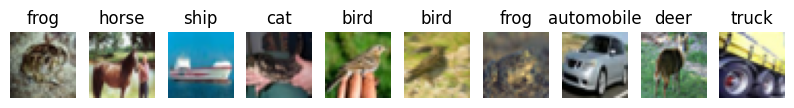

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(train_images[i])
    plt.axis('off')
    plt.title(LABEL_NAMES[train_labels[i]])

plt.show()


## 2) Model Architecture

- Defined augmentation layers
- Helper function for model definition
- Build and compile custom model
- Define callbacks: early stopping and reduce learning rate on plateau.
  - Through the experimentation these are the ones that helped me the most and also the ones that I can understand better.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(CONFIG["IMG_HEIGHT"], CONFIG["IMG_WIDTH"], CONFIG["IMG_CHANNELS"])),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(CONFIG["RANDOM_ROTATION"]),
    tf.keras.layers.RandomZoom(CONFIG["RANDOM_ZOOM"]),
    tf.keras.layers.RandomErasing(
        factor=0.25,
        scale=(0.02, 0.33),
        fill_value=0.0,
        value_range=(0, 1)
    )
])

data_augmentation.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_7 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_4                │ (None, 32, 32, 3)      │             0 │
│ (RandomErasing)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Apply augmentation as part of the model
    x = data_augmentation(inputs)

    # First layer
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # 2nd
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Will try a thid layer for sure....
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Classifier
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

- build and compile model

In [ ]:
print("Building and compiling model...")
model = build_model(
    input_shape=(CONFIG["IMG_HEIGHT"], CONFIG["IMG_WIDTH"], CONFIG["IMG_CHANNELS"]),
    num_classes=len(LABEL_NAMES)
)
optimizer = CONFIG["OPTIMIZER"](learning_rate=CONFIG["LEARNING_RATE"])
loss_fn = 'sparse_categorical_crossentropy'

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
model.summary()

Building and compiling model...


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │     1,049,08

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

- define callbacks, early stopping (have been working like a charm in the past iteration), reduce on plateau, also I found it more useful and it makes more sense than just the scheduler.

In [ ]:
# Use the patience values from CONFIG
early_stopping = EarlyStopping(
    monitor=CONFIG["ES_MONITORED_VARIABLE"],
    patience=CONFIG["ES_PATIENCE"],
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor=CONFIG["RLR_MONITORED_VARIABLE"],
    factor=CONFIG["RLR_FACTOR"],
    patience=CONFIG["RLR_PATIENCE"],
    min_lr=CONFIG["RLR_MIN_LR"]
)

callbacks = [early_stopping, reduce_lr]

## 3) Model Training

- Define tensor flow datasets: Train, Validation and Test.
- Train the model!

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)) \
    .shuffle(train_images.shape[0]) \
    .batch(CONFIG["BATCH_SIZE"]) \
    .prefetch(tf.data.experimental.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels)) \
    .batch(CONFIG["BATCH_SIZE"]) \
    .prefetch(tf.data.experimental.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels)) \
    .batch(CONFIG["BATCH_SIZE"]) \
    .prefetch(tf.data.experimental.AUTOTUNE)

In [ ]:
print("Starting model training...")
history = model.fit(
    train_dataset,
    epochs=CONFIG["EPOCHS"],
    validation_data=val_dataset,
    callbacks=callbacks
)

Starting model training...
Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.3346 - loss: 2.1656 - val_accuracy: 0.5304 - val_loss: 1.3427 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.5289 - loss: 1.3099 - val_accuracy: 0.5546 - val_loss: 1.3968 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.6241 - loss: 1.0538 - val_accuracy: 0.6897 - val_loss: 0.9042 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6687 - loss: 0.9404 - val_accuracy: 0.6431 - val_loss: 1.0764 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.6997 - loss: 0.8641 - val_accuracy: 0.6238 - val_loss: 1.1691 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7170 - loss: 0.8023 - val_accuracy: 0.7050 - val_loss: 0.8754 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14

## 4) Model Evaluation & Exportation

- Trained model evaluation on the separated test data
- Model export to google drive to keep it safe and cozy
- Confusion matrix results
- Accuracy, precision, recall, and F1-score metrics report.
- Loss evolution & Accuracy evolution graphs.

In [ ]:
print("Training finished. Evaluating on test data...")
test_loss, test_accuracy = model.evaluate(test_dataset)

print("-----------------------------------------")
print(f"Final Test Loss:     {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Training finished. Evaluating on test data...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8762 - loss: 0.3855
-----------------------------------------
Final Test Loss:     0.3897
Final Test Accuracy: 87.57%


In [ ]:

print("Saving model to file...")
original_model_name = "cifar10_cnn_model.keras"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_name, extension = os.path.splitext(original_model_name)
formatted_accuracy = f"{test_accuracy * 100:.2f}".replace('.', '')
new_model_name = f"{base_name}_{timestamp}_acc{formatted_accuracy}{extension}"
model.save(f"{CONFIG["DRIVE_DATA_MODELS_PATH"]}/{new_model_name}")
print("Model saved successfully!", new_model_name)

Saving model to file...
Model saved successfully! cifar10_cnn_model_20251028_195127_acc8757.keras


Generating confusion matrix...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


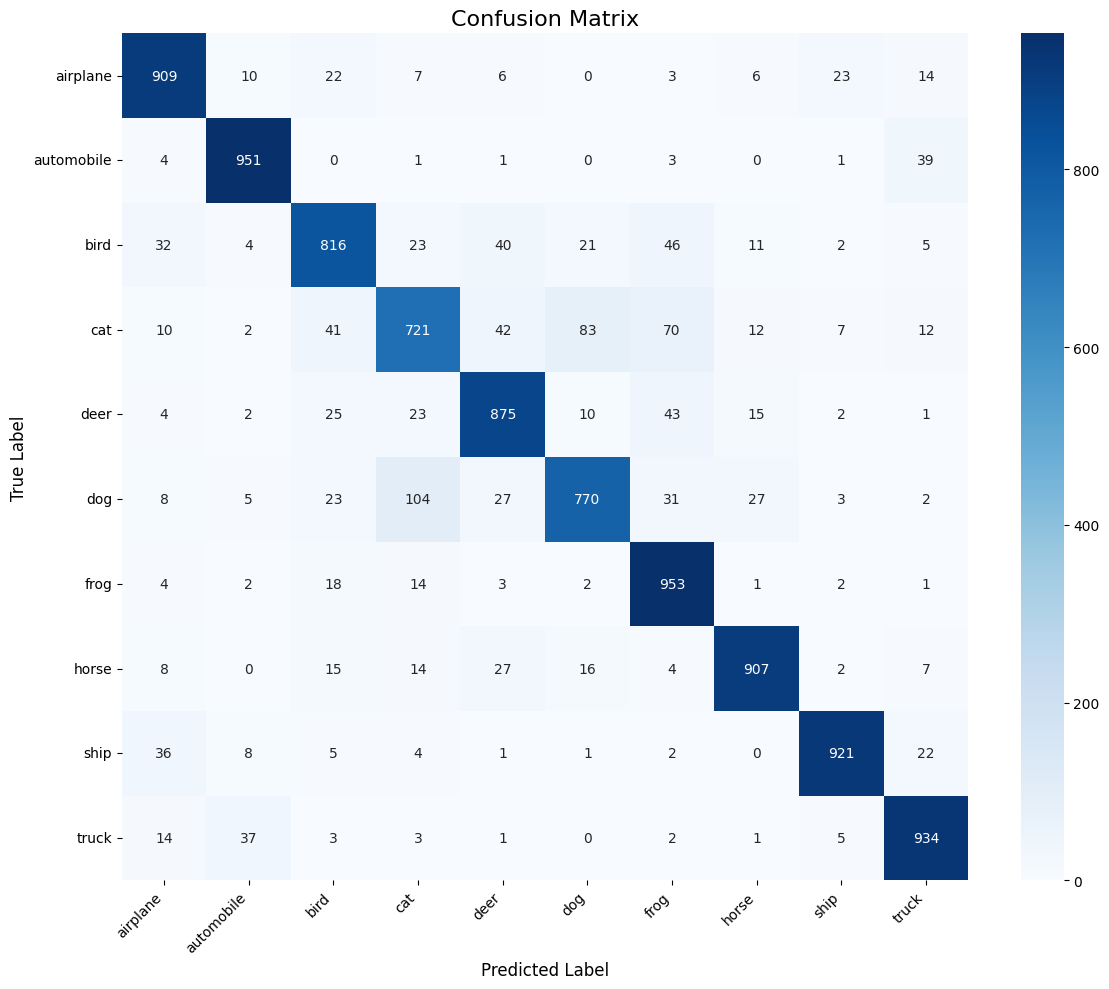

Confusion matrix plot complete.


In [ ]:
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d', # Format as integers
    cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

              precision    recall  f1-score   support

    airplane       0.88      0.91      0.90      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.84      0.82      0.83      1000
         cat       0.79      0.72      0.75      1000
        deer       0.86      0.88      0.87      1000
         dog       0.85      0.77      0.81      1000
        frog       0.82      0.95      0.88      1000
       horse       0.93      0.91      0.92      1000
        ship       0.95      0.92      0.94      1000
       truck       0.90      0.93      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



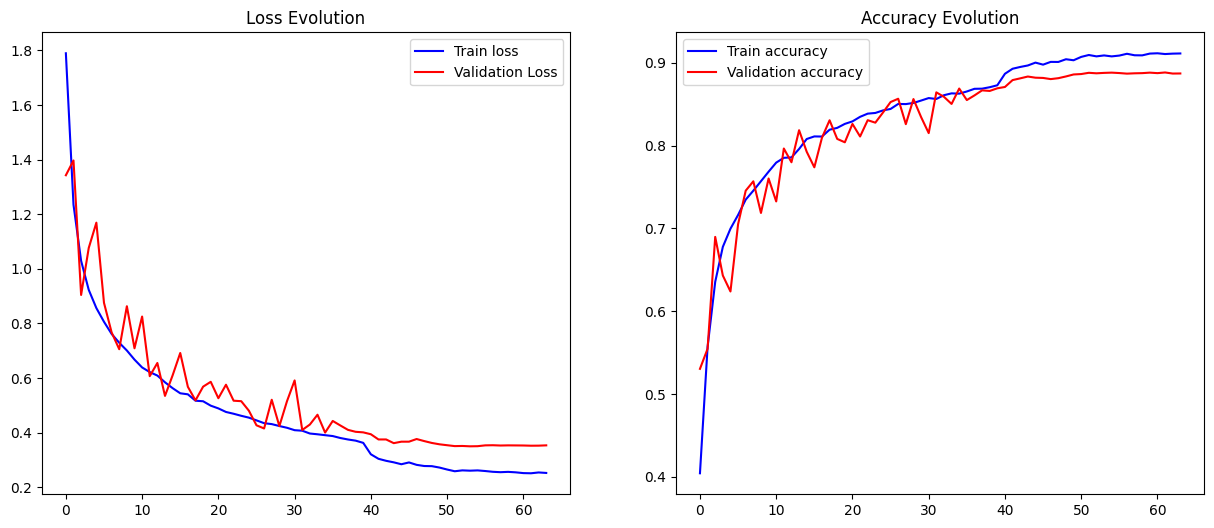

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
plt.plot(model.history.history['loss'], label = 'Train loss', color = 'blue')
plt.plot(model.history.history['val_loss'], label = 'Validation Loss', color = 'red')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'], label = 'Train accuracy', color = 'blue')
plt.plot(model.history.history['val_accuracy'], label = 'Validation accuracy', color = 'red')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()